# Pipeline CPC con datos reales de sEMG

Este notebook ejecuta el pipeline de **Contrastive Predictive Coding** de `01_Pipeline_CPC.ipynb` sobre las señales **sEMG reales** del dataset *Manual Material Handling* (Bassani et al., 2021). Las clases `Encoder`, `AutoRegressive`, `Predictor`, `InfoNCE` y `CPCModel` son **las mismas** del notebook 01 (con una corrección en `InfoNCE` para poder entrenar, ver sección 4): lo que cambia es que `x_demo` (ruido) se reemplaza por ventanas de señal real.

**Decisiones de esta prueba**

| Aspecto | Elección | Motivo |
|---|---|---|
| Señal | `Norm_RMS_1..8` (envolvente RMS, %MVC) | Señal suave, se puede remuestrear a baja frecuencia sin perder información |
| Frecuencia | Remuestreo a **50 Hz** | La frecuencia original varía por archivo (~370–1006 Hz) y hay que unificarla. El paper usa 30 Hz; aquí se eligió 50 Hz (decisión propia) |
| Ventanas | **1 s** (T = 50 muestras), 50 % de traslape | Protocolo de Haresamudram et al. (2020) |
| Archivos | Todas las pruebas no MVC, sin los archivos defectuosos que detectó el EDA | – |
| Partición | Por sujeto: **1–11 entrenamiento**, **12–14 prueba** | El modelo se evalúa con personas que nunca vio |
| Evaluación | Clasificador **lineal** sobre las representaciones congeladas (7 actividades) | Mide la calidad de lo aprendido sin etiquetas |

**Flujo**

1. Setup
2. Carga y remuestreo de los datos (con caché)
3. Ventanas y normalización
4. Clases del modelo CPC (copiadas del notebook 01)
5. Preentrenamiento sin etiquetas
6. Evaluación: clasificación de actividades
7. Cómo leer los resultados

# 1. Setup

In [1]:
import math, time
from pathlib import Path
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Dispositivo:", DEVICE)

PyTorch: 2.11.0
Dispositivo: mps


In [2]:
## Rutas (el notebook vive en notebooks/, los datos en la raíz del repo)
REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_DIR = REPO / "datos_unzipped" / "Data"
LABEL_DIR = REPO / "datos_unzipped" / "Labels"
CACHE_DIR = REPO / "notebooks" / "_cache"
CKPT_DIR = REPO / "checkpoints"                     # ignorado por git
for d in (DATA_DIR, LABEL_DIR):
    assert d.exists(), f"No se encontró {d} (ver la sección Datos del README)"
CACHE_DIR.mkdir(exist_ok=True)
CKPT_DIR.mkdir(exist_ok=True)

## Señal y ventanas
N_CH = 8
SIGNAL_COLS = [f"Norm_RMS_{i}" for i in range(1, N_CH + 1)]
FS_TARGET = 50          # Hz tras el remuestreo
WIN = 50                # muestras por ventana (1 s)
STEP = 25               # salto entre ventanas (50 % de traslape)

## Partición por sujeto
TEST_SUBJECTS = [12, 13, 14]

## Entrenamiento de CPC: Adam y lr 5e-4 como en el paper (que prueba {1e-3, 5e-4}); batch 64 y 15 épocas son decisiones propias
EPOCHS = 15
BATCH_SIZE = 64
LR = 5e-4

## Clases de actividad (orden fijo para tablas y matrices de confusión)
LABELS = ["N", "LF", "K", "PT", "LT", "W", "PF"]
LABEL_NAMES = {"N": "N-pose", "LF": "Levantar del piso", "K": "Mantener", "PT": "Colocar en mesa",
               "LT": "Levantar de mesa", "W": "Caminar/cargar", "PF": "Colocar en piso"}
LABEL_TO_ID = {l: i for i, l in enumerate(LABELS)}
UNLABELED = -1

REFRESH = False         # True = ignorar la caché y volver a leer los CSV (~minutos)

## Estilo de las gráficas
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": "#e4e3df", "grid.linewidth": 0.8, "axes.edgecolor": "#8a8984",
    "axes.labelcolor": "#52514e", "xtick.color": "#52514e", "ytick.color": "#52514e",
    "lines.linewidth": 2, "figure.dpi": 110,
})
C_TRAIN, C_TEST, C_THIRD = "#2a78d6", "#eb6834", "#1baf7a"

# 2. Carga y remuestreo de los datos

### 2.1 Qué archivos se usan

- Solo pruebas de actividad (`Isokin`, `MMH_Bim`, `MMH_One`); los archivos `MVC_*` son la referencia de normalización y no tienen etiquetas de actividad.
- Se excluyen los mismos archivos que el EDA (`00_EDA_dataset.ipynb`) marcó como defectuosos:
  - **señal rota**: algún canal con desviación estándar cruda > 50 mV (electrodo suelto o saturado). Se toma de `_cache/emg_file_stats.csv`, generado por el EDA.
  - **etiquetas inconsistentes**: segmentos vacíos, invertidos o que se traslapan con el siguiente.

In [3]:
files = pd.DataFrame({"data_path": sorted(DATA_DIR.glob("Subj_*/*_EMG_data.csv"))})
files["file"] = files.data_path.map(lambda p: p.name)
files["subject"] = files.file.str.extract(r"Subj_(\d+)_")[0].astype(int)
files["task"] = files.file.str.extract(r"Subj_\d+_(Isokin|MMH_Bim|MMH_One|MVC)")[0]
files["label_path"] = [LABEL_DIR / p.parent.name / p.name.replace("_EMG_data.csv", "_EMG_labels.csv") for p in files.data_path]
files = files[files.task != "MVC"].reset_index(drop=True)

## Señal rota (regla del EDA: std cruda > 50 mV en algún canal)
stats = pd.read_csv(CACHE_DIR / "emg_file_stats.csv")
std_max_mV = stats[[f"raw_std_{c}" for c in range(1, N_CH + 1)]].max(axis=1) * 1e3
BAD_EMG_FILES = set(stats.loc[std_max_mV > 50, "file"])


## Etiquetas inconsistentes (regla del EDA)
def has_bad_labels(path):
    lab = pd.read_csv(path)
    gap_to_next = lab.Start_Frame.shift(-1) - lab.End_Frame
    return bool(((lab.End_Frame - lab.Start_Frame) <= 0).any() or (gap_to_next < 0).any())


BAD_LABEL_FILES = {f for f, p in zip(files.file, files.label_path) if has_bad_labels(p)}

print(f"Pruebas de actividad: {len(files)}")
print(f"Excluidas por señal rota ({len(BAD_EMG_FILES)}): {sorted(BAD_EMG_FILES)}")
print(f"Excluidas por etiquetas inconsistentes ({len(BAD_LABEL_FILES)}): {sorted(BAD_LABEL_FILES)}")
files = files[~files.file.isin(BAD_EMG_FILES | BAD_LABEL_FILES)].reset_index(drop=True)
print(f"Pruebas usadas: {len(files)}")
files.groupby("task").size().rename("pruebas").to_frame().T

Pruebas de actividad: 643
Excluidas por señal rota (3): ['Subj_07_MMH_Bim_R_08kg_Trial_3_EMG_data.csv', 'Subj_07_MMH_Bim_R_12kg_Trial_1_EMG_data.csv', 'Subj_07_MMH_Bim_R_12kg_Trial_2_EMG_data.csv']
Excluidas por etiquetas inconsistentes (2): ['Subj_02_MMH_One_R_02kg_Trial_2_EMG_data.csv', 'Subj_05_Isokin_L_04kg_80bpm_EMG_data.csv']
Pruebas usadas: 638


task,Isokin,MMH_Bim,MMH_One
pruebas,222,249,167


### 2.2 Remuestreo a 50 Hz

Cada CSV tiene su propia frecuencia de muestreo. Para cada archivo:

1. Se estima la frecuencia como en `Process.m`: `muestras / duración`.
2. Se construye una rejilla uniforme a 50 Hz y se **interpola** cada canal de `Norm_RMS`. No hace falta filtro anti-aliasing: `Norm_RMS` ya es una envolvente RMS de 250 muestras, cuyo contenido está muy por debajo de 25 Hz (Nyquist a 50 Hz).
3. Se asigna a cada muestra nueva la **etiqueta** de la fila original más cercana. Las etiquetas de `Labels/` son índices de fila del CSV; lo que queda fuera de los segmentos se marca como *sin etiqueta* (`-1`).

La primera ejecución lee los CSV en paralelo y guarda el resultado en `_cache/semg_norm_rms_50hz.npz` (ignorado por git); las siguientes cargan la caché en segundos.

In [4]:
def load_trial(data_path, label_path):
    d = pd.read_csv(data_path, usecols=["Time"] + SIGNAL_COLS, dtype=np.float64)
    n = len(d)
    fs = n / ((d.Time.iloc[-1] - d.Time.iloc[0]) / 1000)        # frecuencia original de este archivo

    # Etiqueta por fila original (-1 = sin etiqueta)
    lab_orig = np.full(n, UNLABELED, dtype=np.int8)
    for r in pd.read_csv(label_path).itertuples():
        lab_orig[r.Start_Frame:r.End_Frame + 1] = LABEL_TO_ID[r.Label]

    # Rejilla uniforme a FS_TARGET, expresada en índices de fila originales
    n_new = int((n - 1) * FS_TARGET / fs) + 1
    src_idx = np.arange(n_new) * fs / FS_TARGET
    x = d[SIGNAL_COLS].to_numpy()
    x_new = np.stack([np.interp(src_idx, np.arange(n), x[:, c]) for c in range(N_CH)], axis=1)
    lab_new = lab_orig[np.clip(np.rint(src_idx).astype(int), 0, n - 1)]
    return x_new.astype(np.float32), lab_new, fs


CACHE_FILE = CACHE_DIR / "semg_norm_rms_50hz.npz"

if CACHE_FILE.exists() and not REFRESH:
    cache = np.load(CACHE_FILE, allow_pickle=False)
    assert list(cache["files"]) == list(files.file), "La lista de archivos cambió: usa REFRESH = True"
    signals, sample_labels, offsets, fs_orig = cache["signals"], cache["labels"], cache["offsets"], cache["fs"]
    print("Caché cargada:", CACHE_FILE.name)
else:
    t0 = time.time()
    out = Parallel(n_jobs=-1, verbose=0)(delayed(load_trial)(r.data_path, r.label_path) for r in files.itertuples())
    signals = np.concatenate([o[0] for o in out])
    sample_labels = np.concatenate([o[1] for o in out])
    offsets = np.cumsum([0] + [len(o[0]) for o in out])
    fs_orig = np.array([o[2] for o in out])
    np.savez(CACHE_FILE, signals=signals, labels=sample_labels, offsets=offsets, fs=fs_orig,
             files=files.file.to_numpy(dtype=str))
    print(f"{len(files)} archivos leídos en {time.time() - t0:.0f} s -> {CACHE_FILE.name}")

files["fs_orig"] = fs_orig
files["n_50hz"] = np.diff(offsets)
print(f"Señal remuestreada: {signals.shape} (muestras x canales) = {len(signals) / FS_TARGET / 3600:.1f} h de registro")
print(f"Frecuencia original: {fs_orig.min():.0f}–{fs_orig.max():.0f} Hz (mediana {np.median(fs_orig):.0f})")
print(f"Muestras con etiqueta: {(sample_labels != UNLABELED).mean():.0%}")

Caché cargada: semg_norm_rms_50hz.npz
Señal remuestreada: (2267511, 8) (muestras x canales) = 12.6 h de registro
Frecuencia original: 394–1005 Hz (mediana 530)
Muestras con etiqueta: 69%


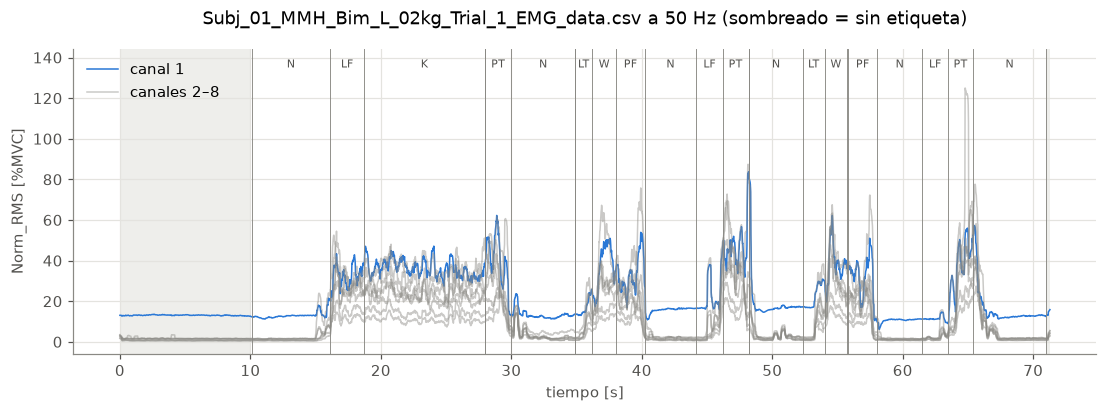

In [5]:
## Ejemplo: una prueba MMH bimanual tras el remuestreo, con los segmentos etiquetados
i = files.index[(files.task == "MMH_Bim") & (files.subject == 1)][0]
x_ex, y_ex = signals[offsets[i]:offsets[i + 1]], sample_labels[offsets[i]:offsets[i + 1]]
t_ex = np.arange(len(x_ex)) / FS_TARGET

fig, ax = plt.subplots(figsize=(12, 3.6))
for c in range(N_CH):
    ax.plot(t_ex, x_ex[:, c], lw=1, color="#8a8984" if c else C_TRAIN, alpha=1 if c == 0 else 0.45,
            label="canal 1" if c == 0 else ("canales 2–8" if c == 1 else None))
# Segmentos: línea en cada cambio de actividad, código de la actividad arriba, zonas sin etiqueta sombreadas
change = np.flatnonzero(np.diff(y_ex) != 0) + 1
top = ax.get_ylim()[1]
for s, e in zip(np.r_[0, change], np.r_[change, len(y_ex)]):
    if y_ex[s] == UNLABELED:
        ax.axvspan(t_ex[s], t_ex[e - 1], color="#e4e3df", alpha=0.6, lw=0)
    else:
        ax.text((t_ex[s] + t_ex[e - 1]) / 2, top * 1.02, LABELS[y_ex[s]], ha="center", va="bottom", fontsize=7, color="#52514e")
    if s > 0:
        ax.axvline(t_ex[s], color="#8a8984", lw=0.6)
ax.set_ylim(top=top * 1.1)
ax.set_title(f"{files.file[i]} a {FS_TARGET} Hz (sombreado = sin etiqueta)", pad=16)
ax.set(xlabel="tiempo [s]", ylabel="Norm_RMS [%MVC]")
ax.legend(loc="upper left", frameon=False)
plt.show()

# 3. Ventanas y normalización

### 3.1 Ventanas de 1 s

Cada prueba se corta en ventanas de `WIN = 50` muestras con salto `STEP = 25`. Las ventanas nunca cruzan de una prueba a otra.

- **Preentrenamiento CPC:** usa **todas** las ventanas de los sujetos de entrenamiento, tengan etiqueta o no (CPC no usa etiquetas).
- **Clasificación:** usa solo ventanas cuya actividad mayoritaria cubre al menos el 50 % de la ventana; esa es su etiqueta.

In [6]:
win_x, win_y, win_subject, win_task = [], [], [], []
for i, r in files.iterrows():
    x_f, y_f = signals[offsets[i]:offsets[i + 1]], sample_labels[offsets[i]:offsets[i + 1]]
    for s in range(0, len(x_f) - WIN + 1, STEP):
        y_w = y_f[s:s + WIN]
        counts = np.bincount(y_w[y_w != UNLABELED], minlength=len(LABELS))
        win_x.append(x_f[s:s + WIN].T)                                          # (N_CH, WIN)
        win_y.append(counts.argmax() if counts.max() >= WIN / 2 else UNLABELED)  # mayoría >= 50 %
        win_subject.append(r.subject)
        win_task.append(r.task)

X = np.stack(win_x)                         # (N, 8, 50)
y = np.array(win_y)
subj = np.array(win_subject)
is_test = np.isin(subj, TEST_SUBJECTS)
labeled = y != UNLABELED

print(f"Ventanas: {X.shape}  (N, canales, T)")
summary = pd.DataFrame({
    "ventanas": [(~is_test).sum(), is_test.sum()],
    "con etiqueta": [(labeled & ~is_test).sum(), (labeled & is_test).sum()],
    "sujetos": [sorted(set(subj[~is_test])), sorted(set(subj[is_test]))],
}, index=["entrenamiento", "prueba"])
summary

Ventanas: (89753, 8, 50)  (N, canales, T)


,ventanas,con etiqueta,sujetos
entrenamiento,70689,49293,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
prueba,19064,12951,"[12, 13, 14]"


In [7]:
## Ventanas etiquetadas por actividad: el desbalance de clases que verá el clasificador
counts = pd.DataFrame({
    "entrenamiento": pd.Series(y[labeled & ~is_test]).map(dict(enumerate(LABELS))).value_counts(),
    "prueba": pd.Series(y[labeled & is_test]).map(dict(enumerate(LABELS))).value_counts(),
}).reindex(LABELS)
counts.index = [f"{l} ({LABEL_NAMES[l]})" for l in LABELS]
counts

,entrenamiento,prueba
N (N-pose),21367,5556
LF (Levantar del piso),4779,1230
K (Mantener),4333,916
PT (Colocar en mesa),7125,2061
LT (Levantar de mesa),4400,1269
W (Caminar/cargar),3774,1015
PF (Colocar en piso),3515,904


### 3.2 Normalización por canal

`Norm_RMS` ya está en %MVC, pero la escala varía mucho entre canales (medianas de pocas unidades, picos de >100 %). Se estandariza cada canal (media 0, desviación 1) con la media y desviación **de los sujetos de entrenamiento únicamente**, para no filtrar información de los sujetos de prueba.

In [8]:
ch_mean = X[~is_test].mean(axis=(0, 2), keepdims=True)
ch_std = X[~is_test].std(axis=(0, 2), keepdims=True)
Xn = ((X - ch_mean) / ch_std).astype(np.float32)

pd.DataFrame({"media [%MVC]": ch_mean.ravel(), "desv. [%MVC]": ch_std.ravel()},
             index=[f"canal {c}" for c in range(1, N_CH + 1)]).round(2).T

,canal 1,canal 2,canal 3,canal 4,canal 5,canal 6,canal 7,canal 8
media [%MVC],24.299999,23.639999,21.09,21.99,20.280001,19.870001,26.049999,26.25
desv. [%MVC],29.100000,28.709999,29.23,31.02,26.400000,26.190001,37.980000,38.75


# 4. Clases del modelo CPC

Copiadas de `01_Pipeline_CPC.ipynb` (sin las celdas de demostración con `x_demo`). La explicación de cada pieza está en ese notebook.

> **Única corrección — `InfoNCE.forward`:** en el notebook 01 devolvía `loss_per_k.detach()`. `CPCModel.info_nce` construye la pérdida final a partir de ese `loss_per_k`, así que la pérdida quedaba **desconectada del grafo** y `loss.backward()` fallaba (`element 0 of tensors does not require grad`). En el notebook 01 no se notaba porque solo se calcula la pérdida sobre `x_demo`, sin entrenar. Aquí se devuelve sin `.detach()`.

In [9]:
@dataclass
class CPCConfig:
    """
    Hiperparámetros de la arquitectura CPC adaptada a sensores corporales
    
    Esta clase es puramente de configuración

    - n_channels: En la práctica va a depender del Dataset, es la cantidad de canales de la señal cruda. 
    
    Parámetros del g_enc: 
    - enc_channels: Canales de salida para cada uno de los bloques Conv1d
    - enc_kernel_size: Tamaño de la ventana que cada encoder mira a la vez (el paper evalúa 3, 5, 7, 9)
    - enc_dropout: probabilidad de apagar una neutrona al azar durante el entrenamiento

    Parámetros del g_ar (GRU):
    - ar_hidden_size: Tamaño del vector de contexto
    - ar_num_lauers: Capas apiladas
    - ar_droput: dropout aplicado a las capas

    Predicciones 
    - n_pred_step: número K de pasos que se busca dar en el futuro
    - n_anchors: número de t instantes de anclaje distintos para calcular la pérdida (para cada paso en el entrenamiento, 
                el modelo toma 4 momentos t distintos de maneta aleatoria), y va a intentar predecir sus respectivos K futuros

    """
    # --- entrada ---
    n_channels: int = 6                     # nº de canales de la señal cruda

    # --- g_enc: encoder convolucional ---
    enc_channels: tuple = (32, 64, 128)     # canales de salida de cada bloque Conv1d
    enc_kernel_size: int = 3                # kernel de cada Conv1d (paper evalúa {3,5,7,9})
    enc_dropout: float = 0.2

    # --- g_ar: modelo autorregresivo ---
    ar_hidden_size: int = 256               # unidades ocultas de la GRU (= dim. de c_t)
    ar_num_layers: int = 2                  # nº de capas apiladas de la GRU
    ar_dropout: float = 0.2                 # dropout entre capas de la GRU

    # --- predicción / pérdida contrastiva ---
    n_pred_steps: int = 12                  # K: horizontes futuros a predecir (paper: óptimo 8-12)
    n_anchors: int = 4                      # nº de instantes de anclaje por batch de entrenamiento

    @property
    def z_dim(self) -> int:
        """Dimensión del espacio latente z_t: el nº de canales de la última capa del encoder."""
        return self.enc_channels[-1]

    @property
    def c_dim(self) -> int:
        """Dimensión del contexto c_t: el tamaño oculto de la GRU."""
        return self.ar_hidden_size

In [10]:
class Encoder(nn.Module):
    """
    g_enc: codificador convolucional genérico.

        n_channels: Canales que tiene cada muestra de señal
        x: (B, n_channels, T)  -->  z: (B, z_dim, T)
        k: Tamaño de la ventaba que cada colvolución va a mirar (núm. de pasos hacia el futuro)

    Arquitectura (Haresamudram, Essa & Plötz, 2020, arXiv:2012.05333): una pila
    de bloques  Conv1d -> ReLU -> Dropout, con padding 'reflect' y SIN stride,
    por lo que la longitud temporal T se conserva de principio a fin.

    No depende de ningún dataset: sólo necesita conocer `n_channels` (dado por
    cfg) y recibe T de forma dinámica según el tensor de entrada.
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        k = cfg.enc_kernel_size
        pad = k // 2  # padding "same": conserva la longitud temporal (stride=1) - Rellena los bordes

        in_channels = (cfg.n_channels,) + cfg.enc_channels[:-1]
        blocks = []
        # Esto va a emparejar los bloques de cada capa. 
        # Por ejemplo (6->32), (32->64), (64->128) y comienza con cada una de las capas de la CNN
        # Ésta misma recenta de convolución se va a aplicar más adelante a cada uno de los elementos de Batche y 
        for c_in, c_out in zip(in_channels, cfg.enc_channels):
            blocks.append(nn.Sequential(
                nn.Conv1d(c_in, c_out, kernel_size=k, padding=pad, padding_mode="reflect"),
                nn.ReLU(inplace=True),
                nn.Dropout(cfg.enc_dropout),
            ))
        self.blocks = nn.ModuleList(blocks)

    # Para la generación de los bloques en el proceso de ejecución
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = x
        for block in self.blocks:
            z = block(z)          # (B, C_in, T) -> (B, C_out, T)
        return z                  # (B, z_dim, T)

In [11]:
class AutoRegressive(nn.Module):
    """
    g_ar: modelo autorregresivo genérico (GRU multicapa).

        z: (B, L, z_dim)  -->  c: (B, L, c_dim)

    Los parámetros de GRU se especifican en la clase cfg. De acuerdo al paper: 
    - input_size: 128
    - hidden_Size: 256
    - num_layer: 2

    c[:, t] resume z[:, :t+1] de forma causal (una GRU nunca mira el futuro),
    que es la propiedad necesaria para usar c_t como predictor de z_{t+k}.

    Arquitectura (Haresamudram, Essa & Plötz, 2020): GRU de 2 capas con 256
    unidades ocultas y dropout entre capas.
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        self.gru = nn.GRU(
            input_size=cfg.z_dim,
            hidden_size=cfg.ar_hidden_size,
            num_layers=cfg.ar_num_layers,
            dropout=cfg.ar_dropout if cfg.ar_num_layers > 1 else 0.0,  # PyTorch exige 0 si num_layers==1
            batch_first=True,
        )

    def forward(self, z: torch.Tensor) -> torch.Tensor:
        c, _ = self.gru(z)        # c: (B, L, c_dim) - Hace un loop sobre todo el eje temporal toma el c_{t-1} e incorpora el nuevo paso z_t
        return c

In [12]:
class Predictor(nn.Module):
    """
    Cabezas de predicción log-bilineal: una transformación lineal W_k por cada
    horizonte futuro k = 1..K, sin sesgo.

        pred_k(c_t) = W_k @ c_t     (aproxima z_{t+k} en el espacio latente)

    El score de CPC (Ec. 3) es f_k(x_{t+k}, c_t) = exp(z_{t+k}^T W_k c_t): esta
    clase sólo calcula W_k c_t; el producto punto contra los candidatos z_{t+k}
    y el softmax los hace la clase InfoNCE.

    Genérica respecto al dataset: sólo depende de c_dim, z_dim y K (cfg).
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        self.n_pred_steps = cfg.n_pred_steps # Definición de los K pasos al futuro

        # Creación de una W_k diferente para cada paso k en el futuro
        self.heads = nn.ModuleList([
            nn.Linear(cfg.c_dim, cfg.z_dim, bias=False) # Matriz de forma (z_dim, c_dim). Pasa de c_t -> vector del mismo tamaño que z_t
            for _ in range(cfg.n_pred_steps) 
        ])

    def forward(self, c_t: torch.Tensor) -> torch.Tensor:
        """
        c_t: (B, c_dim) — contexto en UN instante de anclaje fijo
        -> (K, B, z_dim): una predicción W_k c_t por cada horizonte k
        """
        return torch.stack([head(c_t) for head in self.heads], dim=0) # Esto hace c_t @ head.weight.T

In [13]:
class InfoNCE(nn.Module):
    """
    Pérdida contrastiva de CPC (Ec. 4), con negativos de minibatch, para todos
    los horizontes k = 1..K de una sola vez.

    No depende de ningún dataset: opera únicamente sobre los tensores que
    producen Encoder/AutoRegressive/Predictor. La estrategia de negativos es
    la del paper (Haresamudram et al., 2020): para cada horizonte k, el
    positivo de la secuencia i es z_{t+k}^(i) y los negativos son los
    z_{t+k}^(j) (j != i) de las OTRAS secuencias del mismo batch, en el mismo
    instante t+k.
    """

    def __init__(self, n_pred_steps: int):
        super().__init__()
        self.n_pred_steps = n_pred_steps # K, pasos en el futuro que debo de dar

    def forward(self, preds: torch.Tensor, z: torch.Tensor, t: int):
        """
        preds : (K, B, z_dim)  salidas de Predictor evaluadas en c_t
        z     : (B, L, z_dim)  secuencia completa de latentes (para leer z_{t+k})
        t     : instante de anclaje usado para calcular `preds`

        Devuelve (loss_mean, loss_per_k, acc_per_k); estos dos últimos son
        tensores (K,), uno por horizonte.
        """
        K, B, _ = preds.shape
        device = preds.device
        target = torch.arange(B, device=device)     # la clase correcta de la fila i es i

        loss_per_k = torch.zeros(K, device=device) # Inicializamos el tensor de pérdidas
        acc_per_k = torch.zeros(K, device=device) # Inicializamos el tensor de accuracy

        for k in range(1, K + 1):
            z_future = z[:, t + k, :]                # (B, z_dim): candidatos z_{t+k}
            logits = preds[k - 1] @ z_future.t()     # (B, B): S_ij = pred_i . z_{t+k}^(j)
            loss_per_k[k - 1] = F.cross_entropy(logits, target)
            acc_per_k[k - 1] = (logits.argmax(dim=1) == target).float().mean()

        # CORRECCIÓN respecto al notebook 01: loss_per_k se devuelve SIN .detach(), porque CPCModel.info_nce
        # construye la pérdida a partir de él; con .detach() loss.backward() falla y el modelo no puede entrenarse.
        return loss_per_k.mean(), loss_per_k, acc_per_k.detach()

In [14]:
class CPCModel(nn.Module):
    """
    Modelo CPC completo: Encoder (g_enc) + AutoRegressive (g_ar) + Predictor
    (W_k) + InfoNCE, siguiendo la adaptación a sensores corporales de
    Haresamudram, Essa & Plötz (2020, arXiv:2012.05333).

    Al estar compuesto enteramente por clases genéricas, este modelo no
    conoce nada sobre el dataset de origen: basta con ajustar `cfg.n_channels`
    para entrenarlo sobre EMG, IMU, audio o cualquier otra señal 1D
    multicanal, pasándole tensores (B, n_channels, T).
    """

    def __init__(self, cfg: CPCConfig):
        super().__init__()
        self.cfg = cfg
        self.encoder = Encoder(cfg)
        self.ar = AutoRegressive(cfg)
        self.predictor = Predictor(cfg)
        self.info_nce_loss = InfoNCE(cfg.n_pred_steps)

    def encode(self, x: torch.Tensor):
        """x: (B, n_channels, T) -> z: (B, T, z_dim), c: (B, T, c_dim)"""
        z = self.encoder(x).transpose(1, 2)   # (B, z_dim, T) -> (B, T, z_dim)
        c = self.ar(z)                        # (B, T, c_dim)
        return z, c

    def info_nce(self, x: torch.Tensor, anchors=None):
        """
        Codifica x y calcula la pérdida InfoNCE promediada sobre uno o varios
        instantes de anclaje aleatorios (cfg.n_anchors si `anchors` es None).
        """
        cfg = self.cfg
        z, c = self.encode(x)
        B, L, _ = z.shape
        K = cfg.n_pred_steps

        lo, hi = max(1, L // 8), L - K         # deja sitio para poder leer z_{t+K}
        if hi <= lo:
            raise ValueError(f"Ventana T={L} demasiado corta para K={K} pasos de predicción")
        if anchors is None:
            anchors = torch.randint(lo, hi, size=(cfg.n_anchors,)).tolist()

        losses, accs = [], []
        for t in anchors:
            preds = self.predictor(c[:, t, :])                    # (K, B, z_dim)
            _, loss_per_k, acc_per_k = self.info_nce_loss(preds, z, t)
            losses.append(loss_per_k)
            accs.append(acc_per_k)

        loss_per_k = torch.stack(losses).mean(dim=0)   # promedio sobre anclajes, por k
        acc_per_k = torch.stack(accs).mean(dim=0)
        return loss_per_k.mean(), loss_per_k, acc_per_k

### Configuración para sEMG

Igual que en el notebook 01, salvo `n_channels = 8` (los 8 electrodos). Con `T = 50` y `K = 12`, los anclajes se eligen entre `t = 6` y `t = 37`.

In [15]:
cfg = CPCConfig(n_channels=N_CH, n_pred_steps=12, n_anchors=4)
model = CPCModel(cfg).to(DEVICE)
print(cfg)
print(f"Parámetros: {sum(p.numel() for p in model.parameters()) / 1e6:.2f} M")

## Comprobación de formas con un batch real (el equivalente de x_demo)
x_batch = torch.from_numpy(Xn[:BATCH_SIZE]).to(DEVICE)
with torch.no_grad():
    loss0, _, acc0 = model.info_nce(x_batch)
print(f"Batch real: {tuple(x_batch.shape)} (B, n_channels, T) -> InfoNCE inicial {loss0.item():.3f} "
      f"(azar = log(B) = {math.log(BATCH_SIZE):.3f})")

CPCConfig(n_channels=8, enc_channels=(32, 64, 128), enc_kernel_size=3, enc_dropout=0.2, ar_hidden_size=256, ar_num_layers=2, ar_dropout=0.2, n_pred_steps=12, n_anchors=4)
Parámetros: 1.12 M
Batch real: (64, 8, 50) (B, n_channels, T) -> InfoNCE inicial 4.159 (azar = log(B) = 4.159)


# 5. Preentrenamiento sin etiquetas

Se entrena con **todas** las ventanas de los sujetos 1–11. Cada época recorre las ventanas en orden aleatorio, en batches de 64; para cada batch se promedia InfoNCE sobre 4 anclajes aleatorios y los 12 horizontes.

Las ventanas de los sujetos de prueba solo se usan para **monitorear** la pérdida (no se elige ningún modelo con ellas).

**Referencia:** con B = 64 candidatos, adivinar al azar da una pérdida de `log(64) ≈ 4.16` y una accuracy de `1/64 ≈ 0.016`.

**Ojo al comparar curvas:** la métrica de entrenamiento se calcula con *dropout* activo (y promediando durante la época, mientras el modelo aún mejora), y la de prueba con el modelo en modo evaluación al final de la época. Por eso la curva de prueba puede quedar *por encima* de la de entrenamiento sin que haya nada raro.

In [16]:
X_train_t = torch.from_numpy(Xn[~is_test]).to(DEVICE)    # todas las ventanas de entrenamiento
X_test_t = torch.from_numpy(Xn[is_test]).to(DEVICE)


@torch.no_grad()
def evaluate_cpc(model, X_t, n_batches=100):
    # InfoNCE en un subconjunto fijo de batches (mismos anclajes y ventanas en cada época)
    model.eval()
    g = torch.Generator().manual_seed(SEED)
    idx = torch.randperm(len(X_t), generator=g)[: n_batches * BATCH_SIZE].view(n_batches, BATCH_SIZE)
    lo, hi = max(1, WIN // 8), WIN - cfg.n_pred_steps
    losses, accs = [], []
    for b in idx:
        anchors = torch.randint(lo, hi, (cfg.n_anchors,), generator=g).tolist()
        loss, _, acc = model.info_nce(X_t[b.to(X_t.device)], anchors=anchors)
        losses.append(loss.item())
        accs.append(acc.cpu())
    return float(np.mean(losses)), torch.stack(accs).mean(0).numpy()


optimizer = torch.optim.Adam(model.parameters(), lr=LR)
history = []
n_steps = len(X_train_t) // BATCH_SIZE
print(f"{EPOCHS} épocas x {n_steps} pasos (batch {BATCH_SIZE})")

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    model.train()
    perm = torch.randperm(len(X_train_t), device=DEVICE)
    run_loss, run_acc = 0.0, 0.0
    for step in range(n_steps):
        xb = X_train_t[perm[step * BATCH_SIZE:(step + 1) * BATCH_SIZE]]
        loss, _, acc_per_k = model.info_nce(xb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        run_loss += loss.item()
        run_acc += acc_per_k.mean().item()

    test_loss, test_acc_k = evaluate_cpc(model, X_test_t)
    history.append({"epoch": epoch, "train_loss": run_loss / n_steps, "train_acc": run_acc / n_steps,
                    "test_loss": test_loss, "test_acc": test_acc_k.mean(), "test_acc_k": test_acc_k})
    print(f"época {epoch:2d} | train loss {run_loss / n_steps:.3f} acc {run_acc / n_steps:.3f} | "
          f"test loss {test_loss:.3f} acc {test_acc_k.mean():.3f} | {time.time() - t0:.0f} s")

CKPT = CKPT_DIR / "cpc_semg_norm_rms.pt"
torch.save({"model": model.state_dict(), "cfg": cfg.__dict__, "ch_mean": ch_mean, "ch_std": ch_std,
            "fs": FS_TARGET, "win": WIN, "test_subjects": TEST_SUBJECTS}, CKPT)
print("Modelo guardado en", CKPT.relative_to(REPO))

15 épocas x 1104 pasos (batch 64)


época  1 | train loss 2.115 acc 0.335 | test loss 1.692 acc 0.591 | 56 s


época  2 | train loss 1.232 acc 0.603 | test loss 1.311 acc 0.693 | 114 s


época  3 | train loss 0.938 acc 0.703 | test loss 1.184 acc 0.717 | 172 s


época  4 | train loss 0.820 acc 0.741 | test loss 1.064 acc 0.751 | 230 s


...

época 11 | train loss 0.455 acc 0.855 | test loss 0.757 acc 0.807 | 641 s


época 12 | train loss 0.441 acc 0.859 | test loss 0.714 acc 0.821 | 700 s


época 13 | train loss 0.427 acc 0.863 | test loss 0.707 acc 0.819 | 765 s


época 14 | train loss 0.417 acc 0.866 | test loss 0.739 acc 0.812 | 825 s


época 15 | train loss 0.403 acc 0.870 | test loss 0.707 acc 0.815 | 885 s
Modelo guardado en checkpoints/cpc_semg_norm_rms.pt


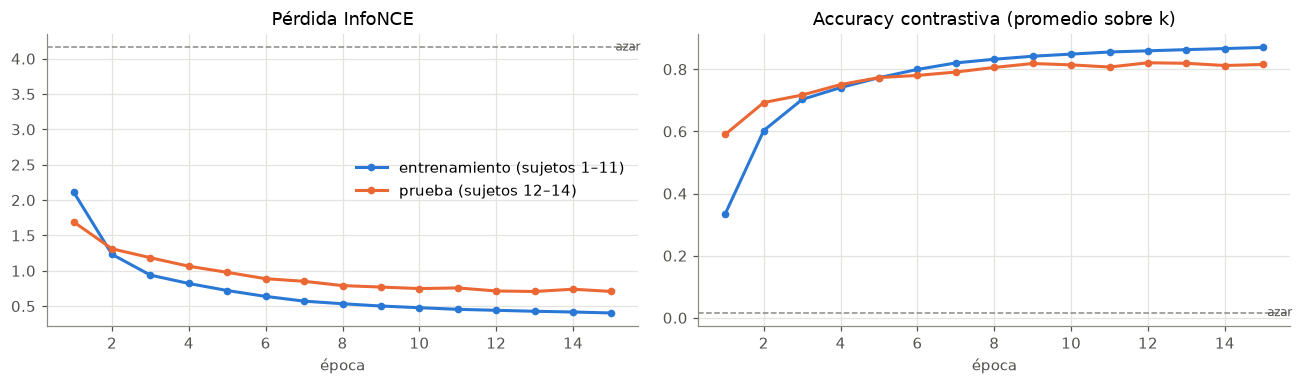

In [17]:
hist = pd.DataFrame(history)
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
for ax, metric, title, ref in ((axes[0], "loss", "Pérdida InfoNCE", math.log(BATCH_SIZE)),
                                 (axes[1], "acc", "Accuracy contrastiva (promedio sobre k)", 1 / BATCH_SIZE)):
    ax.plot(hist.epoch, hist[f"train_{metric}"], color=C_TRAIN, marker="o", ms=4, label="entrenamiento (sujetos 1–11)")
    ax.plot(hist.epoch, hist[f"test_{metric}"], color=C_TEST, marker="o", ms=4, label="prueba (sujetos 12–14)")
    ax.axhline(ref, color="#8a8984", ls="--", lw=1)
    ax.text(hist.epoch.iloc[-1], ref, " azar", va="center", ha="left", fontsize=8, color="#52514e")
    ax.set(xlabel="época", title=title)
axes[0].legend(frameon=False)
plt.tight_layout()
plt.show()

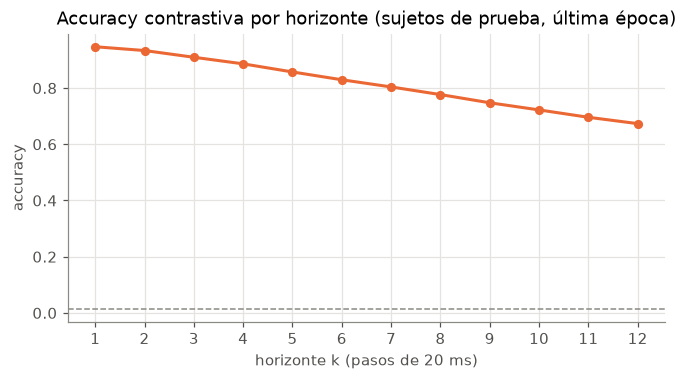

In [18]:
## Figura 3 del paper: la tarea es más difícil cuanto más lejos se predice
acc_k = hist.test_acc_k.iloc[-1]
fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(range(1, cfg.n_pred_steps + 1), acc_k, color=C_TEST, marker="o", ms=5)
ax.axhline(1 / BATCH_SIZE, color="#8a8984", ls="--", lw=1)
ax.set(xlabel="horizonte k (pasos de 20 ms)", ylabel="accuracy", xticks=range(1, cfg.n_pred_steps + 1),
       title="Accuracy contrastiva por horizonte (sujetos de prueba, última época)")
plt.show()

# 6. Evaluación: clasificación de actividades

Protocolo de **evaluación lineal**: se congela el modelo CPC, se extrae una representación por ventana y se entrena una **regresión logística** para predecir las 7 actividades. Si CPC aprendió algo útil sin etiquetas, un clasificador *lineal* debería bastar para separar las actividades.

- **Representación:** el contexto de la GRU al final de la ventana, `c_T` (256 dimensiones), que resume toda la ventana.
- **Comparaciones:**
  - *CPC sin entrenar*: la misma arquitectura con pesos aleatorios. Separa lo que aporta el preentrenamiento de lo que aporta la arquitectura.
  - *Estadísticos simples*: media, desviación, mínimo y máximo por canal (32 valores). Una referencia clásica sin aprendizaje profundo.
- **Métricas:** accuracy y **F1 macro** (promedio por clase; importante porque `N` domina el conjunto). La regresión usa `class_weight="balanced"` por la misma razón.

In [19]:
@torch.no_grad()
def cpc_features(model, X_np, batch=1024):
    model.eval()
    feats = []
    for s in range(0, len(X_np), batch):
        _, c = model.encode(torch.from_numpy(X_np[s:s + batch]).to(DEVICE))
        feats.append(c[:, -1, :].cpu().numpy())        # c_T: contexto al final de la ventana
    return np.concatenate(feats)


def stat_features(X_np):
    return np.concatenate([X_np.mean(2), X_np.std(2), X_np.min(2), X_np.max(2)], axis=1)


tr, te = labeled & ~is_test, labeled & is_test
torch.manual_seed(SEED)
random_model = CPCModel(cfg).to(DEVICE)             # misma arquitectura, sin entrenar

feature_sets = {
    "CPC preentrenado": cpc_features(model, Xn),
    "CPC sin entrenar": cpc_features(random_model, Xn),
    "Estadísticos simples": stat_features(Xn),
}

results, predictions = [], {}
for name, feats in feature_sets.items():
    clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=3000, class_weight="balanced"))
    clf.fit(feats[tr], y[tr])
    pred = clf.predict(feats[te])
    predictions[name] = pred
    results.append({"representación": name, "dimensión": feats.shape[1],
                    "accuracy": accuracy_score(y[te], pred), "F1 macro": f1_score(y[te], pred, average="macro")})

results = pd.DataFrame(results).set_index("representación")
results.round(3)

,dimensión,accuracy,F1 macro
representación,,,
CPC preentrenado,256,0.385,0.290
CPC sin entrenar,256,0.422,0.268
Estadísticos simples,32,0.476,0.292


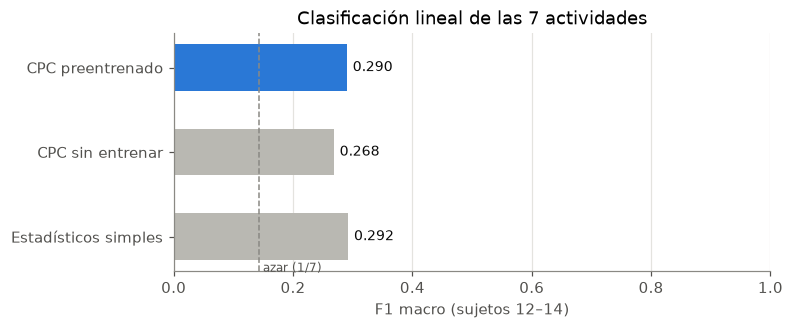

In [20]:
fig, ax = plt.subplots(figsize=(7, 2.8))
names = results.index[::-1]
ax.barh(names, results.loc[names, "F1 macro"], color=[C_TRAIN if n == "CPC preentrenado" else "#b9b8b2" for n in names],
        height=0.55)
for i, n in enumerate(names):
    ax.text(results.loc[n, "F1 macro"] + 0.01, i, f"{results.loc[n, 'F1 macro']:.3f}", va="center", fontsize=9, color="#0b0b0b")
ax.axvline(1 / len(LABELS), color="#8a8984", ls="--", lw=1)
ax.text(1 / len(LABELS), -0.45, " azar (1/7)", fontsize=8, color="#52514e", va="bottom")
ax.set_axisbelow(True)
ax.set(xlim=(0, 1), xlabel="F1 macro (sujetos 12–14)", title="Clasificación lineal de las 7 actividades")
ax.grid(axis="y", visible=False)
plt.show()

              precision    recall  f1-score   support

           N      0.774     0.534     0.632      5556
          LF      0.214     0.326     0.258      1230
           K      0.193     0.110     0.140       916
          PT      0.278     0.213     0.241      2061
          LT      0.241     0.305     0.269      1269
           W      0.229     0.209     0.218      1015
          PF      0.182     0.525     0.271       904

    accuracy                          0.385     12951
   macro avg      0.302     0.318     0.290     12951
weighted avg      0.464     0.385     0.406     12951



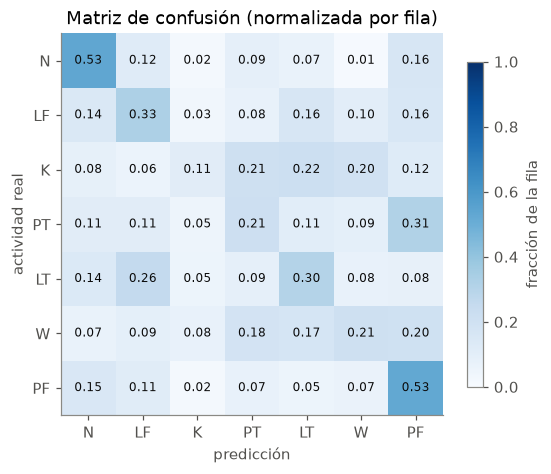

In [21]:
## Detalle del CPC preentrenado: qué actividades confunde
pred = predictions["CPC preentrenado"]
print(classification_report(y[te], pred, labels=range(len(LABELS)), target_names=LABELS, digits=3, zero_division=0))

cm = confusion_matrix(y[te], pred, labels=range(len(LABELS)), normalize="true")
fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set(xticks=range(len(LABELS)), xticklabels=LABELS, yticks=range(len(LABELS)), yticklabels=LABELS,
       xlabel="predicción", ylabel="actividad real", title="Matriz de confusión (normalizada por fila)")
ax.grid(False)
for i in range(len(LABELS)):
    for j in range(len(LABELS)):
        ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cm[i, j] > 0.55 else "#0b0b0b")
fig.colorbar(im, shrink=0.8, label="fracción de la fila")
plt.show()

# 7. Cómo leer los resultados

- **Preentrenamiento:** la pérdida InfoNCE debe bajar claramente de `log(64) ≈ 4.16` y la accuracy contrastiva subir muy por encima de `1/64`. Si las curvas de prueba siguen a las de entrenamiento, lo aprendido generaliza a sujetos nuevos. La accuracy por horizonte debe caer al crecer `k`: predecir 240 ms adelante es más difícil que 20 ms.
- **Clasificación:** lo relevante es la diferencia entre *CPC preentrenado* y *CPC sin entrenar*: esa es la ganancia atribuible al aprendizaje sin etiquetas. La comparación con *estadísticos simples* indica si la representación aprendida supera a una referencia clásica.
- **Confusiones esperables:** actividades con esfuerzo muscular parecido pero a distinta altura (`LF` vs `LT`, `PT` vs `PF`) son difíciles de separar solo con sEMG de 1 s; la captura de movimiento (MVNX) aporta justo esa información.

**Siguientes pasos posibles**

- Más épocas de preentrenamiento (el paper usa 150; aquí `EPOCHS = 15` para una prueba).
- Validación cruzada por sujeto (*leave-subjects-out* en varios pliegues) en lugar de una sola partición.
- Clasificador MLP en lugar de lineal, o *fine-tuning* del encoder, como en Haresamudram et al. (2020).
- Probar `Norm_V` o `Raw_V` filtrada a mayor frecuencia, y añadir los canales de la captura de movimiento.